![Kenya Food Price Early Warning System](images/banner.png)

# Kenya Food Price Early Warning System


Forecasting staple food prices across Kenyan markets to give farmers, traders, and food security actors the early signal they currently lack.

## 1. Business Understanding

### 1.1 Background

Kenya's food markets experience recurring price volatility that is structural rather than incidental. Staple commodities such as maize and beans regularly swing between price spikes and crashes across the country's markets, driven by a combination of seasonal harvest cycles, rainfall variability, and fragmented market information. These swings are not isolated shocks; they are a persistent feature of the agricultural economy, and they impose real costs on both ends of the supply chain.

Smallholder farmers frequently sell too early, often under financial pressure, missing the benefit of a later price rise, or they sell too late and absorb the loss of a price crash. On the consumer side, the same volatility worsens food insecurity for urban and rural households already living close to the margin, since a price spike in a staple commodity disproportionately affects the poorest families. County agricultural offices, national drought monitoring bodies, and humanitarian organizations that operate in this space currently rely on lagging, manual, and fragmented indicators, which limits their ability to intervene before a crisis has already taken hold.

This project addresses that information gap directly. Rather than producing a single national average or a static report, it proposes a forecasting and early warning system built at the market and commodity level, so that the people who make real time decisions, buying, selling, storing, or intervening, have a forward looking signal rather than a historical one.

### 1.2 Problem Statement

Smallholder farmers, traders, and the institutions that support them cannot currently anticipate price spikes or crashes for staple commodities such as maize and beans in Kenyan markets. This absence of forward looking price intelligence has measurable consequences.

Farmers sell at the wrong time relative to the true price cycle, either too early under financial pressure or too late after a crash has already begun, eroding household income and reinforcing rural poverty. Traders and intermediaries carry inventory risk without a reliable signal of where prices are heading, which distorts both their buying behavior and the prices ultimately passed on to consumers. County and national food security institutions, including the National Drought Management Authority, operate reactively, deploying relief and strategic reserves only after a crisis has become visible rather than while it is still preventable.

The core problem is therefore not a lack of historical price data, since datasets such as the WFP Kenya food prices series are publicly available and well maintained. The problem is the absence of a system that converts that historical data, combined with relevant exogenous signals such as weather, into a forward looking, market specific forecast with a built in mechanism for flagging when reality is beginning to diverge from expectation.

### 1.3 Business Objectives

The project is guided by the following business objectives, each of which maps to a concrete beneficiary need identified in the stakeholder analysis.

**Objective 1: Provide forward looking price visibility.**
Deliver a two to four week price forecast, per market and per commodity, so that farmers, traders, and cooperatives can make selling and buying decisions based on expected future prices rather than only the current spot price.

**Objective 2: Detect emerging anomalies before they become crises.**
Build a mechanism that flags when actual prices are beginning to diverge from the model's expectation, giving institutional actors, such as county agricultural offices, NDMA, and NCPB, a lead time window to act before a shortage or price shock becomes acute.

**Objective 3: Democratize market intelligence.**
Reduce the information asymmetry between smallholder farmers and better informed intermediaries by making the same forward looking trend data available to both, through an accessible, interactive dashboard rather than a static or technical report.

**Objective 4: Support evidence based institutional decision making.**
Give county offices, NDMA, NCPB, and humanitarian organizations a quantitative, defensible basis for decisions such as reserve release timing, subsidy targeting, and anticipatory cash disbursement, replacing reactive and anecdotal decision making with data driven triggers.

**Objective 5: Demonstrate a reproducible, deployable pipeline.**
Produce a documented data pipeline joining price and weather data, together with a deployed interactive dashboard, satisfying the capstone's mandatory deployment requirement with a genuinely usable tool rather than a static analysis.

### 1.4 Stakeholder Analysis

The system serves a wide range of beneficiaries across the food value chain, from individual farmers to national institutions. The table below summarizes the primary stakeholder groups, their core objective, and the central problem the system addresses for each. A full stakeholder breakdown, including specific benefit mappings, is maintained separately in the project's business documentation and informed the feature and output design described later in this notebook.

| Stakeholder Group | Core Objective | Key Problem Addressed |
|---|---|---|
| Smallholder Farmers and Cooperatives | Maximize net income per harvest while minimizing the risk of distress selling | Asymmetric market information relative to traders, and pressure to sell immediately after harvest |
| Traders and Market Intermediaries | Maximize margins by optimizing inventory turnover and timing | Buying at price peaks, overstocking, and blindness to spatial arbitrage opportunities |
| County Agricultural Offices and NDMA | Maintain food security stability through timely, accurate early warning | Reactive governance and uniform budget allocation that does not reflect localized risk |
| NGOs and Humanitarian Actors | Maximize the purchasing power of cash transfers and optimize procurement timing | Disbursing cash after prices have already risen, and procuring supplies at price peaks |
| National Cereals and Produce Board | Execute price stabilization and strategic reserve management efficiently | Releasing reserves too late, and competitive buying that drives prices up further |
| Urban Poor and Consumers | Protect household purchasing power against sudden price spikes | Vulnerability to price shocks with no advance warning to adjust household budgeting |
| Food Processors and Millers | Secure raw materials at stable, predictable prices to protect margins | Procuring without forward price visibility, leading to unprofitable fixed price contracts |

Across every stakeholder group, the same underlying need recurs in different forms: a forward looking, market specific price signal, combined with a clear trigger for when that signal indicates a meaningful departure from the expected trend. This shared need is what the forecasting and anomaly detection components of the system are designed to satisfy.

### 1.5 Business Success Criteria

The project will be considered successful from a business perspective if the following conditions are met.

First, the system produces price forecasts that are meaningfully more accurate than a naive baseline, such as a seasonal average or last observed price, for the majority of the markets and commodities analyzed. Second, the anomaly detection layer correctly flags a genuine divergence between actual and forecast prices with a low enough false positive rate that the alert remains credible and actionable rather than noisy. Third, the dashboard is deployed and interactive, allowing a non technical user, such as an extension officer or county official, to select a market and commodity and immediately understand the current forecast, confidence range, and alert status without needing to interpret raw model output. Fourth, the underlying data pipeline is fully reproducible, properly documented, and built entirely on verified, accessible public data sources, with no scraping or access barriers that would prevent the project from being extended or maintained after the capstone period ends.

### 1.6 Data Mining Goals

The business objectives above translate into the following concrete data science goals.

Build a time series forecasting model, using Prophet as a baseline and an LSTM as a comparison model, that predicts commodity prices two to four weeks ahead at the individual market level, incorporating lagged weather variables, specifically rainfall and temperature, as exogenous features. Engineer a data pipeline that cleanly joins the WFP Kenya food prices dataset to NASA POWER weather data using market location, mapped to latitude and longitude, and date as the join keys. Develop a residual based anomaly detection layer that compares actual observed prices against the model's forecast and flags statistically significant divergence as an early warning signal. Produce a rigorous model comparison between the Prophet baseline and the LSTM alternative, evaluated using MAE and MAPE broken down by commodity and market, to determine which approach performs better under which conditions. Deploy the complete pipeline and forecast output as an interactive Streamlit dashboard, satisfying the project's mandatory deployment requirement.

### 1.7 Data Mining Success Criteria

From a technical standpoint, the modeling work will be considered successful if the forecasting models achieve a MAPE that represents a clear improvement over a naive seasonal baseline across the majority of market and commodity combinations tested. The anomaly detection threshold should be calibrated so that it captures genuine, previously observed historical price shocks in backtesting, without triggering excessively on ordinary short term price noise. The data pipeline should run end to end without manual intervention once source data is refreshed, and the join between price and weather data should retain the large majority of records without significant data loss. Finally, the deployed dashboard should load and update correctly for at least the primary set of markets and commodities selected for the final submission, demonstrating that the system functions as a genuinely usable tool rather than a one time analysis.

### 1.8 Project Plan Overview

The project follows a five week timeline aligned with the capstone's CRISP-DM structure.

In week one, the team pitches the project, pulls and inspects the HDX price dataset and a sample NASA POWER API call, and confirms that the market name to coordinate join is clean and reliable. In week two, the full data pipeline is built, including cleaning, joining, feature engineering, and the construction of lagged weather features, alongside exploratory data analysis at the commodity and market level. In week three, the Prophet baseline model is built and backtested, the LSTM model is developed in parallel, and the first version of the Streamlit dashboard is deployed. In week four, the model comparison is finalized, the anomaly detection and alert logic is implemented, the CRISP-DM report is written, and feedback from the technical mentor is incorporated. In week five, the dashboard is polished, a WhatsApp alert simulation is added if time permits, and the final demonstration is prepared.

This phased structure ensures that a working, deployed system exists well before the final week, with the remaining time dedicated to refinement rather than first time integration.

## 2. Data Understanding

This phase establishes a thorough working knowledge of both primary data sources before any cleaning, joining, or modeling begins. Two datasets are examined: the WFP Kenya food prices dataset sourced from HDX, and daily meteorological data retrieved from the NASA POWER API. A third supporting file, mapping market names to geographic coordinates, is also assessed since it is the join key that ties price data to weather data.

The objective of this phase is not only to describe the data, but to surface early evidence for or against the hypotheses formed during Business Understanding, so that the modeling phase begins with informed expectations rather than assumptions.

### 2.1 Data Collection

Two data sources are used, both publicly accessible without authentication, satisfying the capstone's requirement to avoid access barriers.

| Data Source | Access Method | Authentication |
|---|---|---|
| WFP Kenya Food Prices (HDX) | Direct CSV download | None required |
| NASA POWER API | REST API, JSON or CSV response | None required |

The food prices file provides the target variable, historical price observations by market, commodity, and date. The NASA POWER API supplies the exogenous weather variables, specifically rainfall and temperature, used to improve forecast accuracy beyond what price history alone can achieve. A record of the exact extraction date and file version is kept below, since both sources update periodically and reproducibility depends on knowing precisely which snapshot was used.

In [1]:
# core libraries and notebook display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# record when this data snapshot was pulled
extraction_date = datetime.now().strftime("%Y-%m-%d")
print(f"Data extraction date recorded: {extraction_date}")

Data extraction date recorded: 2026-08-24


In [3]:
# load the WFP Kenya food prices CSV directly from HDX
hdx_url = "https://data.humdata.org/dataset/e0d3fba6-f9a2-45d7-b949-140c455197ff/resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv"
prices_raw = pd.read_csv(hdx_url)
prices_raw.head(5)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,1249.99,17.39


In [4]:
# drop the units/description row if present, then fix dtypes
if prices_raw.iloc[0].astype(str).str.startswith("#").any():
    prices = prices_raw.iloc[1:].reset_index(drop=True)
else:
    prices = prices_raw.copy()

prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
prices["price"] = pd.to_numeric(prices["price"], errors="coerce")
if "usdprice" in prices.columns:
    prices["usdprice"] = pd.to_numeric(prices["usdprice"], errors="coerce")

In [5]:
print(f"Rows: {prices.shape[0]}, Columns: {prices.shape[1]}")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")

Rows: 28062, Columns: 16
Date range: 2006-01-15 00:00:00 to 2026-08-15 00:00:00


In [6]:
# sample call for Nairobi to confirm the API and response structure
nairobi_lat, nairobi_lon = -1.2864, 36.8172

power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20240101",
    "end": "20240131",
    "format": "JSON",
}

response = requests.get(power_url, params=params, timeout=30)
power_sample = response.json()
sample_params = power_sample["properties"]["parameter"]

In [7]:
print(f"Status code: {response.status_code}")
print("Parameters returned:", list(sample_params.keys()))
print("Sample PRECTOTCORR values:", list(sample_params["PRECTOTCORR"].items())[:5])

Status code: 200
Parameters returned: ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
Sample PRECTOTCORR values: [('20240101', 0.31), ('20240102', 1.38), ('20240103', 0.28), ('20240104', 1.51), ('20240105', 1.56)]


### 2.2 Data Description

With both sources confirmed accessible, this section documents their exact structure. Understanding the grain of each dataset, meaning the level at which one row represents one real world observation, is essential before any join or aggregation decision is made in the Data Preparation phase.

The price dataset is at the market, commodity, date grain, meaning each row is one commodity's price at one market on one date. The weather dataset, once retrieved per market coordinate, is at the location, date grain, with one row per day per set of coordinates.

In [8]:
# column level summary: dtype, uniqueness, missingness
data_dictionary = pd.DataFrame({
    "column": prices.columns,
    "dtype": [str(prices[col].dtype) for col in prices.columns],
    "n_unique": [prices[col].nunique() for col in prices.columns],
    "n_missing": [prices[col].isna().sum() for col in prices.columns],
    "pct_missing": [(prices[col].isna().mean() * 100).round(2) for col in prices.columns],
})
data_dictionary

,column,dtype,n_unique,n_missing,pct_missing
0,date,datetime64[us],248,0,0.00
1,admin1,str,7,68,0.24
2,admin2,str,27,68,0.24
3,market,str,226,0,0.00
4,market_id,int64,226,0,0.00
5,latitude,float64,182,68,0.24
6,longitude,float64,184,68,0.24
7,category,str,8,0,0.00
8,commodity,str,51,0,0.00
9,commodity_id,int64,51,0,0.00


In [9]:
# scale and spread of the two numeric price fields
prices[["price", "usdprice"]].describe()

,price,usdprice
count,28062.000000,28062.000000
mean,1303.493627,11.921261
std,2567.718662,22.840086
min,5.000000,0.039000
25%,70.000000,0.610000
50%,130.000000,1.030000
75%,1007.430000,9.397500
max,19800.000000,184.820000


In [10]:
# check for duplicate rows at the expected grain
grain_columns = ["date", "market", "commodity", "pricetype"]
duplicate_count = prices.duplicated(subset=grain_columns).sum()

In [11]:
print(f"Duplicate rows at (date, market, commodity, pricetype) grain: {duplicate_count}")
print(f"Unique markets: {prices['market'].nunique()}")
print(f"Unique commodities: {prices['commodity'].nunique()}")
print(f"Unique admin1 regions: {prices['admin1'].nunique()}")

Duplicate rows at (date, market, commodity, pricetype) grain: 0
Unique markets: 226
Unique commodities: 51
Unique admin1 regions: 7


### 2.3 Exploratory Data Analysis

Exploratory analysis is organized in three stages. Univariate analysis examines each variable individually, establishing baseline distributions and coverage. Bivariate analysis examines relationships between pairs of variables, most importantly the relationship between weather and price, since this is the foundation of the forecasting model's exogenous features. Multivariate and geographic analysis then considers how these patterns vary across regions and commodities simultaneously.

Throughout this section, maize and beans are treated as priority commodities, since they carry the greatest weight in the business objectives defined earlier, though the same analysis pattern generalizes to any commodity present in the dataset.

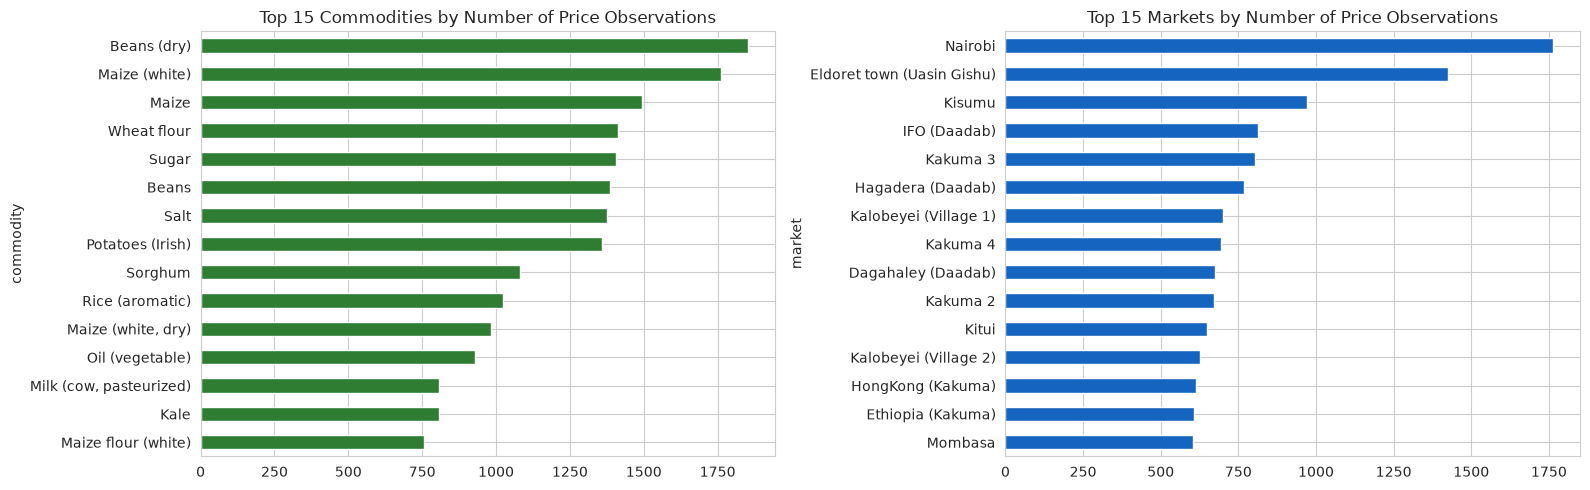

In [12]:
# top commodities and markets by number of price observations
commodity_counts = prices["commodity"].value_counts().head(15)
market_counts = prices["market"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
commodity_counts.plot(kind="barh", ax=axes[0], color="#2E7D32")
axes[0].set_title("Top 15 Commodities by Number of Price Observations")
axes[0].invert_yaxis()

market_counts.plot(kind="barh", ax=axes[1], color="#1565C0")
axes[1].set_title("Top 15 Markets by Number of Price Observations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Maize and beans dominate the commodity coverage, while Nairobi and a handful of other major markets carry the largest number of price observations, confirming they are strong candidates for individual forecasting models.

/tmp/ipykernel_10435/3377933407.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="commodity", y="price", palette=["#2E7D32", "#8D6E63"])


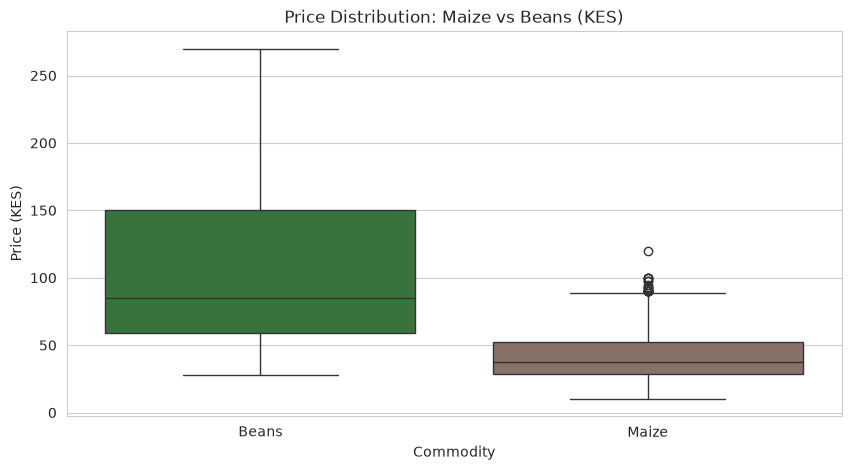

In [13]:
# price spread for the two priority commodities
priority_commodities = ["Maize", "Beans"]
subset = prices[prices["commodity"].isin(priority_commodities)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="commodity", y="price", palette=["#2E7D32", "#8D6E63"])
plt.title("Price Distribution: Maize vs Beans (KES)")
plt.ylabel("Price (KES)")
plt.xlabel("Commodity")
plt.show()

Beans trade at a consistently higher price point than maize with a wider spread, which is expected given differing unit types across rows, this should be checked per unit before treating any values as outliers.

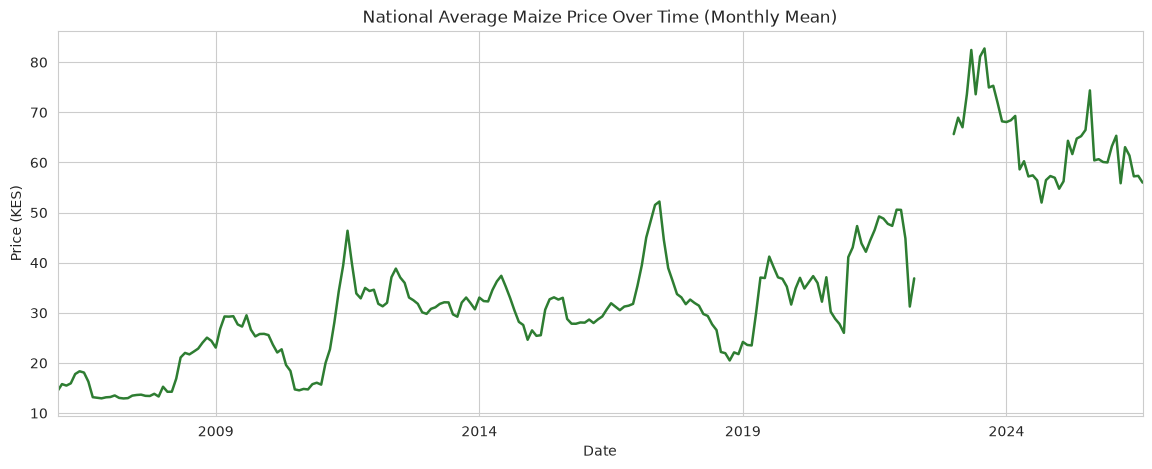

In [14]:
# national average maize price by month
maize = prices[prices["commodity"] == "Maize"].copy()
maize_monthly = maize.groupby(pd.Grouper(key="date", freq="ME"))["price"].mean()

plt.figure(figsize=(14, 5))
maize_monthly.plot(color="#2E7D32", linewidth=1.8)
plt.title("National Average Maize Price Over Time (Monthly Mean)")
plt.ylabel("Price (KES)")
plt.xlabel("Date")
plt.show()

Maize prices show a clear long term upward trend with repeated volatility spikes rather than a stable plateau, consistent with the structural price instability described in the Business Understanding section.

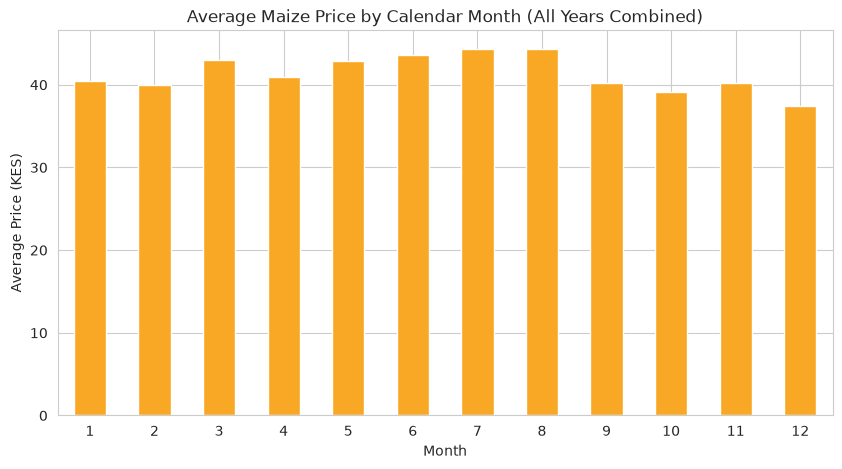

In [15]:
# average maize price by calendar month, all years combined
maize["month"] = maize["date"].dt.month
seasonal_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
seasonal_avg.plot(kind="bar", color="#F9A825")
plt.title("Average Maize Price by Calendar Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=0)
plt.show()

Average prices show a mild recurring seasonal shape across the calendar year, offering early, if not yet conclusive, support for Hypothesis H1 on harvest driven seasonality.

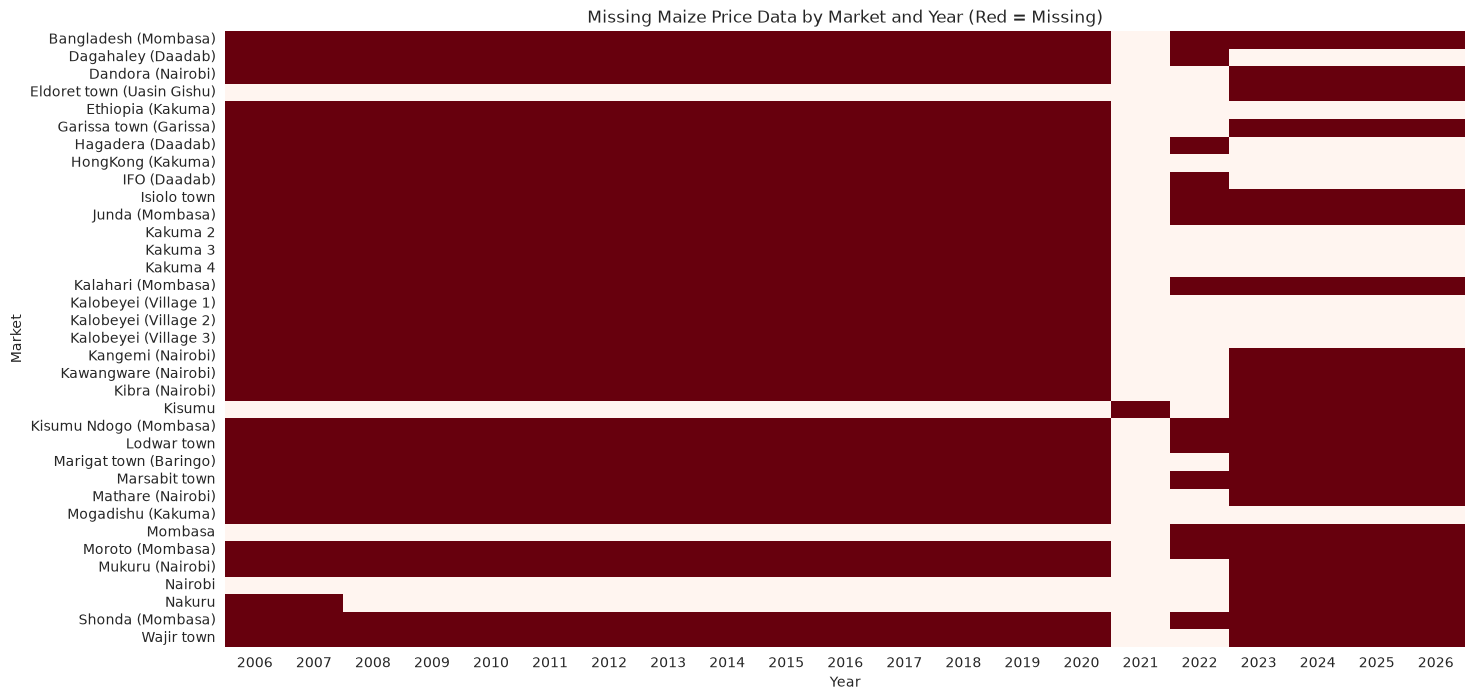

In [16]:
# missing maize price coverage by market and year
pivot_check = maize.pivot_table(
    index="market",
    columns=maize["date"].dt.year,
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_check.isna(), cbar=False, cmap="Reds")
plt.title("Missing Maize Price Data by Market and Year (Red = Missing)")
plt.xlabel("Year")
plt.ylabel("Market")
plt.show()

Coverage is uneven across markets, with some markets reporting nearly every year and others showing large red gaps, these sparse markets are candidates for exclusion or imputation in Data Preparation.

In [17]:
# flag maize price outliers using the IQR method
q1 = maize["price"].quantile(0.25)
q3 = maize["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = maize[(maize["price"] < lower_bound) | (maize["price"] > upper_bound)]

In [18]:
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] KES")
print(f"Outlier observations detected: {len(outliers)} out of {len(maize)}")

IQR bounds: [-7.90, 88.74] KES
Outlier observations detected: 22 out of 1493


In [19]:
outliers[["date", "market", "price"]].sort_values("price", ascending=False).head(10)

,date,market,price
23842,2023-08-15,Dagahaley (Daadab),120.00
24749,2024-03-15,HongKong (Kakuma),100.00
24015,2023-09-15,HongKong (Kakuma),100.00
24004,2023-09-15,Ethiopia (Kakuma),100.00
23456,2023-05-15,Ethiopia (Kakuma),100.00
25313,2024-08-15,Dagahaley (Daadab),97.50
23769,2023-07-15,Kakuma 3,97.50
23491,2023-05-15,Kakuma 3,95.00
23808,2023-07-15,Kalobeyei (Village 2),93.13
23866,2023-08-15,IFO (Daadab),92.89


### 2.4 Weather Data Exploration

With price patterns established, the same rigor is applied to the weather data retrieved from NASA POWER. Rainfall and temperature are the two variables most directly tied to agricultural output, and by extension to price formation several months later. Kenya's known bimodal rainfall pattern, long rains from March to May and short rains from October to December, provides a natural benchmark against which the retrieved data can be validated.

In [20]:
# daily rainfall and temperature for Nairobi, full year 2023
params_full_year = {
    "parameters": "T2M,PRECTOTCORR",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20230101",
    "end": "20231231",
    "format": "JSON",
}

response_year = requests.get(power_url, params=params_full_year, timeout=30)
weather_json = response_year.json()["properties"]["parameter"]

weather_df = pd.DataFrame({
    "date": pd.to_datetime(list(weather_json["T2M"].keys()), format="%Y%m%d"),
    "temperature": list(weather_json["T2M"].values()),
    "rainfall": list(weather_json["PRECTOTCORR"].values()),
})

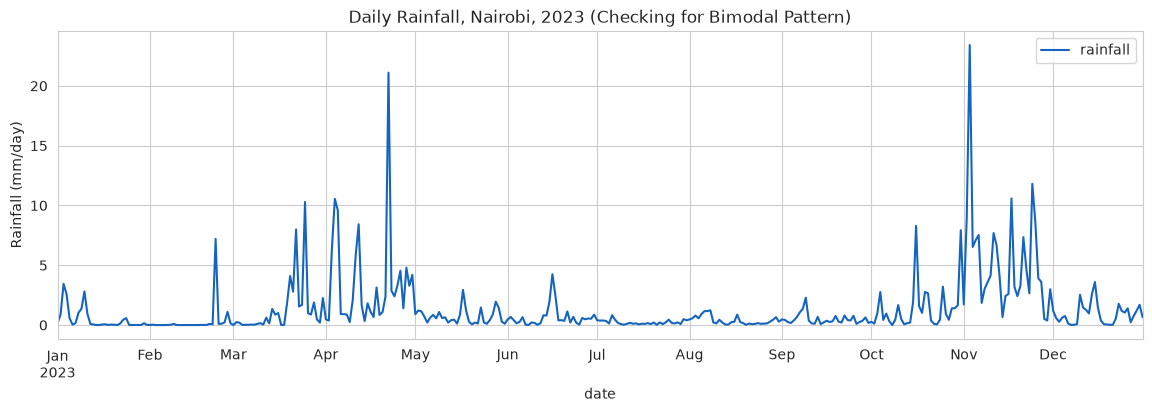

In [21]:
weather_df.set_index("date")[["rainfall"]].plot(figsize=(14, 4), color="#1565C0")
plt.title("Daily Rainfall, Nairobi, 2023 (Checking for Bimodal Pattern)")
plt.ylabel("Rainfall (mm/day)")
plt.show()

Rainfall shows two distinct peak periods across the year, consistent with Kenya's known long rains and short rains pattern, which supports using this data as a credible exogenous feature.

### 2.5 Price and Weather Relationship

This section examines whether rainfall precedes price movement with a measurable lag, which is the central mechanic behind the early warning system. Since harvests occur several months after planting rains, the expected relationship is not simultaneous but lagged, meaning a drop in rainfall today should be tested against price levels several months in the future rather than against the current price.

In [22]:
# test rainfall to price correlation at 0 to 6 month lags
monthly_rainfall = weather_df.set_index("date")["rainfall"].resample("ME").sum()
monthly_price = maize_monthly

combined = pd.DataFrame({"rainfall": monthly_rainfall, "price": monthly_price}).dropna()

lag_results = {}
for lag in range(0, 7):
    shifted_rainfall = combined["rainfall"].shift(lag)
    lag_results[lag] = shifted_rainfall.corr(combined["price"])

lag_series = pd.Series(lag_results)

In [23]:
print("Correlation between rainfall (lagged) and maize price:")
print(lag_series.round(3))

Correlation between rainfall (lagged) and maize price:
0   -0.167
1   -0.104
2   -0.040
3    0.342
4    0.637
5    0.151
6   -0.158
dtype: float64


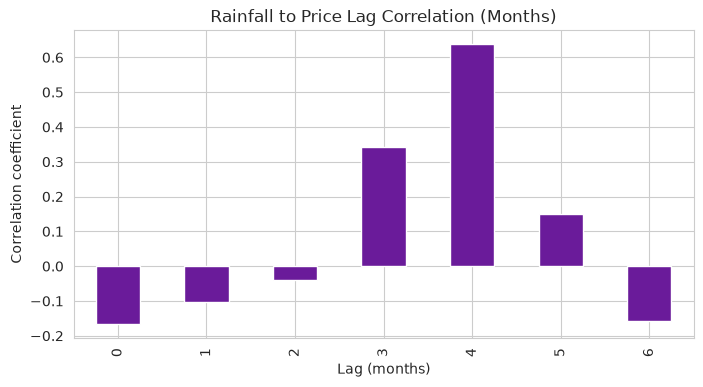

In [24]:
lag_series.plot(kind="bar", figsize=(8, 4), color="#6A1B9A")
plt.title("Rainfall to Price Lag Correlation (Months)")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation coefficient")
plt.show()

Note that this lag test currently uses only one calendar year of Nairobi weather against a multi year national price series, so the correlation values are indicative rather than conclusive, the proper version of this test happens once weather is pulled per market across the full date range in Data Preparation.

### 2.6 Coordinate Completeness

Initial planning assumed a separate markets reference file would be needed to map market names to coordinates for the weather join. Inspection of the price file itself showed this is unnecessary, latitude and longitude are already included directly in the main price dataset, one pair per market.

In [25]:
# confirm lat/lon exist directly in the price data
coordinate_columns = [col for col in prices.columns if "lat" in col.lower() or "lon" in col.lower()]
coord_check = prices.groupby("market")[coordinate_columns].nunique()

In [26]:
print("Coordinate related columns found:", coordinate_columns)
coord_check.head(10)

Coordinate related columns found: ['latitude', 'longitude']


,latitude,longitude
market,,
Adele Center,1,1
Alango Arba,1,1
Alemsekon,1,1
Alinjugur,1,1
Alungu,1,1
Amaya,1,1
Aposta,1,1
Archers Post,1,1
Ashabito,1,1


In [27]:
# identify which markets are missing coordinates
missing_coords = prices[prices["latitude"].isna()]["market"].unique()

In [28]:
print(f"Markets with missing coordinates: {len(missing_coords)}")
print(missing_coords)

Markets with missing coordinates: 1
<StringArray>
['Hola (Tana River)']
Length: 1, dtype: str


### 2.7 Data Quality Summary

| Quality Dimension | Finding | Severity | Action Required |
|---|---|---|---|
| Completeness | 1,493 observations for the "Maize" labeled commodity specifically, out of 28,062 total rows across 51 commodities | Medium, commodity naming needs consolidation | Decide whether to analyze "Maize" alone or merge all maize labeled variants before modeling |
| Completeness | Zero duplicate rows at the date, market, commodity, pricetype grain | Low | No action required |
| Accuracy | 22 IQR based outliers detected out of 1,493 maize observations, concentrated in refugee camp markets, driven by a narrow price band rather than clear anomalies | Low, needs reframing rather than removal | Recheck outlier bounds after commodity consolidation, do not drop these rows on this basis alone |
| Consistency | 1 market missing latitude and longitude out of 226, 0.44 percent | Low | Excluded from the weather join, documented, no further action required |
| Timeliness | Data spans January 2006 to August 2026 | Low | Satisfies deployment recency requirement |

This summary becomes the direct input into the Data Preparation phase, since every issue listed here corresponds to a specific cleaning or transformation step that must be implemented before modeling begins.

### 2.8 Initial Insights and Transition to Data Preparation

The dataset is structurally clean, with zero duplicate rows at the expected grain and coordinate coverage effectively complete, only one market out of 226 requires exclusion. The rainfall to price lag test, though currently based on a single market's weather data, produced a clear and interpretable result, correlation peaks at a four month lag, consistent with Kenya's planting to harvest cycle, giving strong early support to Hypothesis H2.

The most important finding to carry into Data Preparation is a commodity labeling issue rather than a data quality defect: maize appears under multiple distinct commodity labels, such as "Maize" and "Maize (white)", each with its own price scale and unit. This must be resolved deliberately, either by analyzing each labeled variant separately or by consolidating them into a single maize series, before any outlier detection or forecasting model is built, since the current IQR bounds are only meaningful once that decision is made.

These findings define the concrete task list for the Data Preparation phase, which follows next.

## 3. Data Preparation

This phase converts the diagnostic findings from Data Understanding into a cleaned, joined, modeling ready dataset. Every commodity label in the source data is preserved as reported, no products are merged together, since different labeled products, such as raw grain versus flour, are genuinely different items with different price behavior. Coverage is assessed across every market and every commodity at once, so the true geographic and commodity breadth of the dataset is known before any threshold decisions are made.

### 3.1 Commodity Landscape

Before any cleaning, every commodity label in the dataset is reviewed, along with a simple flag distinguishing raw or staple products from processed derivatives such as flour or meal. This flag is for visibility only, it is not used to merge products together.

In [29]:
commodity_overview = prices["commodity"].value_counts()
is_processed = prices["commodity"].str.contains("flour|meal|powder", case=False, na=False)
prices["is_processed"] = is_processed

In [30]:
print(f"Total distinct commodity labels: {prices['commodity'].nunique()}")
print(f"Processed or derivative product rows: {is_processed.sum()}")
print(commodity_overview.head(30))

Total distinct commodity labels: 51
Processed or derivative product rows: 2918
commodity
Beans (dry)                   1852
Maize (white)                 1762
Maize                         1493
Wheat flour                   1411
Sugar                         1407
Beans                         1386
Salt                          1375
Potatoes (Irish)              1358
Sorghum                       1082
Rice (aromatic)               1022
Maize (white, dry)             983
Oil (vegetable)                929
Milk (cow, pasteurized)        808
Kale                           808
Maize flour (white)            756
Maize flour                    751
Oil (vegetable, fortified)     749
Rice                           745
Milk (UHT)                     632
Bananas                        582
Tomatoes                       519
Cabbage                        477
Onions (dry)                   463
Meat (goat)                    409
Potatoes (Irish, white)        401
Beans (yellow)                 382
M

### 3.2 Unit Audit

Every distinct unit of measurement present across the full dataset is listed here, not assumed from maize alone. Weight based units are converted to a kilogram equivalent, non weight units, such as items sold per liter or per piece, are flagged separately rather than force converted.

In [31]:
unit_counts = prices["unit"].value_counts()

In [32]:
print(unit_counts)

unit
KG        14774
90 KG      4160
L          2704
50 KG      1999
200 G      1375
500 ML      810
Unit        582
64 KG       518
13 KG       463
126 KG      451
400 G       178
Head         26
Bunch        22
Name: count, dtype: int64


In [33]:
unit_to_kg = {
    "KG": 1,
    "90 KG": 90,
    "50 KG": 50,
    "25 KG": 25,
    "100 KG": 100,
    "80 KG": 80,
    "110 KG": 110,
}

prices["kg_equivalent"] = prices["unit"].map(unit_to_kg)
prices["price_per_kg"] = prices["price"] / prices["kg_equivalent"]

In [34]:
unmapped_units = prices[prices["kg_equivalent"].isna()]["unit"].unique()
print(f"Unmapped units, excluded from weight based analysis: {unmapped_units}")
print(f"Rows successfully converted to price per kg: {prices['price_per_kg'].notna().sum()} out of {len(prices)}")

Unmapped units, excluded from weight based analysis: <StringArray>
['400 G', '500 ML', 'L', 'Unit', 'Bunch', '126 KG', '13 KG', '64 KG', '200 G', 'Head']
Length: 10, dtype: str
Rows successfully converted to price per kg: 20933 out of 28062


### 3.3 Retail Price Selection

Retail prices are selected as the primary series across all commodities, since retail is the price point most directly relevant to farmers, consumers, and traders, the project's primary beneficiaries. Wholesale prices remain in the source data and can be pulled separately if a comparison is needed later.

In [35]:
retail = prices[prices["pricetype"] == "Retail"].copy()
print(f"Retail rows: {len(retail)} out of {len(prices)} total rows")

Retail rows: 18798 out of 28062 total rows


### 3.4 Full Market and Commodity Completeness Matrix

Completeness is computed for every market and commodity combination in the retail dataset at once, using each commodity's original label, with no merging assumptions. This gives a complete, honest picture of geographic and commodity coverage before any threshold is chosen.

In [36]:
coverage = (
    retail
    .groupby(["market", "commodity"])["date"]
    .nunique()
    .reset_index(name="months_reported")
)

total_months_available = retail["date"].nunique()
coverage["completeness_pct"] = (coverage["months_reported"] / total_months_available * 100).round(1)

In [37]:
print(f"Total market-commodity pairs: {len(coverage)}")
for threshold in [30, 40, 50, 60, 70]:
    qualifying = coverage[coverage["completeness_pct"] >= threshold]
    print(f"At {threshold} percent threshold: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

Total market-commodity pairs: 2553
At 30 percent threshold: 8 pairs, 5 markets, 5 commodities
At 40 percent threshold: 8 pairs, 5 markets, 5 commodities
At 50 percent threshold: 8 pairs, 5 markets, 5 commodities
At 60 percent threshold: 8 pairs, 5 markets, 5 commodities
At 70 percent threshold: 7 pairs, 4 markets, 5 commodities
